Chapter 26
# 计算、可视化成对距离
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
import matplotlib as mpl
import seaborn as sns
import string
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean
import os
# 如果文件夹不存在，创建文件夹
if not os.path.isdir("Figures"):
    os.makedirs("Figures")

In [6]:
x = np.arange(-2, 2.1, 1)   # [-2, -1, 0, 1, 2]
y = np.arange(-2, 2.1, 1)   # [-2, -1, 0, 1, 2]
XX, YY = np.meshgrid(x, y)

In [7]:
XX

array([[-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.]])

In [8]:
YY

array([[-2., -2., -2., -2., -2.],
       [-1., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 2.,  2.,  2.,  2.,  2.]])

In [9]:
# 产生随机数
num = 26
np.random.seed(0) # 种子
data = np.random.randint(10 + 1, size=(num, 2)) # 0-10---26*2
labels = list(string.ascii_uppercase)

In [10]:
labels

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

In [11]:
cmap = mpl.cm.get_cmap('RdYlBu_r')

/tmp/ipykernel_4823/642181128.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdYlBu_r')


Python 中的 string 模块提供了许多字符串处理相关的函数和常量，可以方便地进行字符串操
作。比如，string.ascii_uppercase: 包含所有大写 ASCII 字母 (A-Z) 的字符串，
string.digits: 包含所有数字 (0-9) 的字符串。

b
从 scipy.spatial 中导入 distance_matrix 函数，用于计算多个点之间的成对距离矩
阵。它接受点坐标的数组或列表，然后计算每两个点之间的距离，并返回一个矩阵，其中的每个元素表
示两个点之间的距离。

c
从 scipy.spatial.distance 模块中导入了 euclidean 函数，用来计算两点欧氏距离。

d
设置随机数生成器的种子 seed 为 0，从而使随机数的生成具有确定性，保证实验结果可重复
性。

e
在 [0, 10] 区间之内生成随机整数，形状为 26 行、2 列。

f
生成 A-Z 大写字母字符串，并将其转换为列表。

g
从 matplotlib 通过 cm.get_cmap() 函数来获取一个名为 'RdYlBu_r' 的颜色映射对
象。'RdYlBu_r' 是一个预定义的颜色映射名称，它表示一种从红色 Rd 到黄色 Yl 再到蓝色 Bu 的颜色渐变，且颜色映射反向 (预定颜色映射字符串末尾带 _r 表示反向)。鸢尾花书也管颜色映射叫色
谱。


颜色映射对象通常被用于将数据的数值范围 [0, 1] 映射到一系列颜色中的某个位置。这个数值
范围一般默认为 [0, 1]，其中 0 对应着颜色映射的起始位置，1 对应着颜色映射的结束位置。颜色
映射会将 [0, 1] 区间内的数据值线性地映射到预定义的颜色序列上。
在使用 Matplotlib 中的颜色映射对象时，可以使用 matplotlib.colors.Normalize()
函数将数据规范化到 [0, 1] 区间，然后再将规范化后的数据传递给颜色映射对象来获取对应的颜
色。


#111

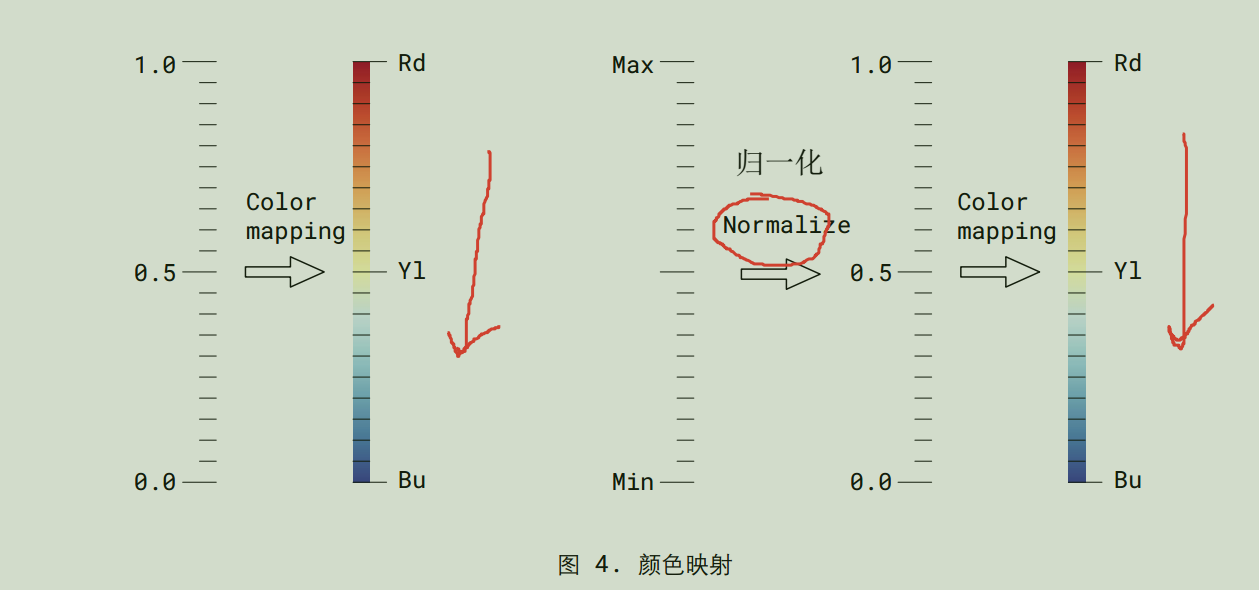

h
使用了 Python 中的 enumerate 函数和 itertools.combinations 函数，用于在数据
data 的所有两两组合之间进行循环迭代，并在每次迭代中获取索引和组合数据。

i
利用 scipy.spatial.distance.euclidean() 计算两个点之间的欧氏距离。

k
把图 3 欧氏距离转化为 [0, 1] 之间的数。显然在图 3 平面上，最大的距离为
10 2  。

l
通过 for 循环利用 annotate() 给每个散点添加字母标签。

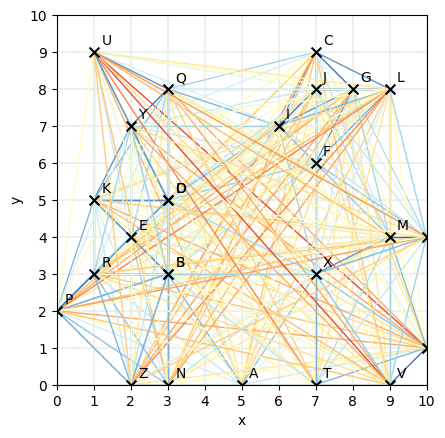

In [12]:
fig, ax = plt.subplots()
# 绘制成对线段
for i, d in enumerate(itertools.combinations(data, 2)): #data26个点；从中取出2个点
    d_idx = euclidean(d[0],d[1]) # 计算两点的距离
    plt.plot([d[0][0],d[1][0]],
             [d[0][1],d[1][1]],  #两点的xy的值
             color = cmap(d_idx/np.sqrt(2)/10),lw = 1)
ax.scatter(data[:,0],data[:,1], #第一列与第二列也就是 x与y
           marker = 'x',color = 'k',s = 50,zorder=100)
# 添加标签
for i, txt in enumerate(labels):
    ax.annotate(txt,(data[i,0] + 0.2, data[i,1] + 0.2)) #添加标签

ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_xticks(np.arange(11)) #刻度线的位置set_xticks 只决定刻度位置，不决定刻度标签的文字。
ax.set_yticks(np.arange(11))
plt.xlabel('x'); plt.ylabel('y')
ax.grid(ls='--',lw=0.25,color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')
# fig.savefig('Figures/成对距离连线.svg', format='svg')

m
计算 26 个散点的成对距离矩阵，这个矩阵的大小为 26 × 26。这个矩阵的主对角线 (图 3 虚
线) 的元素代表某个点到自身的距离，即 0。我们容易发现，
图 3 这个矩阵沿着主对角线对称；因此这个距离矩阵也叫对称矩阵 (symmetric matrix)。换
个角度来看，我们只需要这个 26 × 26 矩阵中除主对角线以外，下三角 (图 5) 或上三角矩阵的元素
信息。
n

利用 seaborn.heatmap() 绘制成对距离热图。

<AxesSubplot:>

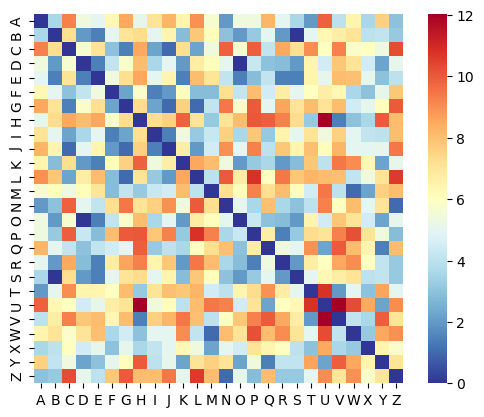

In [ ]:
# 计算成对距离矩阵
pairwise_distances = distance_matrix(data, data)  #26*26
fig, ax = plt.subplots()
sns.heatmap(pairwise_distances, #距离矩阵
            cmap = 'RdYlBu_r', square = True, #方块
            xticklabels = labels,yticklabels = labels,
            ax = ax)
# fig.savefig('Figures/成对距离矩阵热图.svg', format='svg')